In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
from typing import Tuple, List
import os
import re

In [34]:
def parse_filenames(df: pd.DataFrame) -> pd.DataFrame:
    """Processes a DataFrame to extract sample name, cleaning method, proportion, and mix method.
    
    It reads from a column 'Unnamed: 0', creates 'sample_name',
    'clean_method', 'proportion', and 'mix_method' columns, and then drops 
    the original column.

    Args:
        df: The input pandas DataFrame.

    Returns:
        A new DataFrame with the processed columns.
    """
    
    # Work on a copy to avoid side effects and SettingWithCopyWarning
    df_copy = df.copy()
    
    # The name of the column containing the filenames
    filename_col = 'Unnamed: 0'

    def parse_filename(filename: str) -> Tuple[str, str, str, str]:
        """Parses a filename string to extract sample name, cleaning method, proportion, and mix method.

        Args:
            filename: The filename string to parse.

        Returns:
            A tuple containing the sample name, clean method, proportion, and mix method.
        """
        
        # Clean the filename by removing the extension and any whitespace
        clean_name = filename.replace('.fcs', '').strip()
        
        sample_name_base = ''
        clean_method = ''
        
        # Logic to handle different filename formats to extract clean_method
        if clean_name.startswith('flowmop_'):
            clean_method = 'flowmop'
            sample_name_base = clean_name.removeprefix('flowmop_')
        elif clean_name.endswith('_flowcut'):
            clean_method = 'flowcut'
            sample_name_base = clean_name.removesuffix('_flowcut')
        elif clean_name.endswith('_peacoqc'):
            clean_method = 'peacoqc'
            sample_name_base = clean_name.removesuffix('_peacoqc')
        else:
            sample_name_base = clean_name

        # Extract mix_method and proportion from the sample_name
        parts = sample_name_base.split('_')
        
        mix_method = ''
        proportion = ''
        sample_name = ''

        if len(parts) > 2:
            mix_method = parts[-1]
            proportion_str = parts[-2]
            sample_name = '_'.join(parts[:-2])

            # Use regex to split the proportion string into 2-digit chunks
            proportions_list = re.findall(r'(\d{2})', proportion_str)
            proportion = ','.join(proportions_list)
        else:
            sample_name = sample_name_base
            
        return sample_name, clean_method, proportion, mix_method

    # Apply the parsing function to the column to create new columns
    df_copy[['sample_name', 'clean_method', 'proportion', 'mix_method']] = df_copy[filename_col].apply(
        lambda name: pd.Series(parse_filename(name))
    )
    # Drop the original 'Unnamed: 0' column
    df_processed = df_copy.drop(columns=[filename_col])
    
    return df_processed

In [35]:
synth_dir = r"C:\Users\Tony\Documents\github_remotes\FlowMOP\figs\fig_2_data\fig_2_analysis"
csvs = [f for f in os.listdir(synth_dir) if f.endswith('.csv')]
normal_times = [pd.read_csv(synth_dir + "\\" + csv) for csv in csvs if 'combos' in csv]
smallcut_times = [pd.read_csv(synth_dir + "\\" + csv) for csv in csvs if 'smallcut' in csv]
for i, time in enumerate(normal_times): 
    normal_times[i] = normal_times[i][~normal_times[i]['Unnamed: 0'].str.contains('Mean', na=False)]
    normal_times[i] = normal_times[i][~normal_times[i]['Unnamed: 0'].str.contains('SD', na=False)]
for i, time in enumerate(smallcut_times): 
    smallcut_times[i] = smallcut_times[i][~smallcut_times[i]['Unnamed: 0'].str.contains('Mean', na=False)]
    smallcut_times[i] = smallcut_times[i][~smallcut_times[i]['Unnamed: 0'].str.contains('SD', na=False)]

In [36]:
for i, time in enumerate(normal_times): 
    normal_times[i] = parse_filenames(time).sort_values(by=['sample_name',"mix_method","proportion"]).reset_index(drop=True)

overall_counts_normal = normal_times[1]["Count"]

# Some specific reformatting
normal_times[1]["Count"] = overall_counts_normal * normal_times[1]["passedtime | Freq. of Parent (%)"]/100
normal_times[1].drop(columns=["passedtime | Freq. of Parent (%)","Unnamed: 6"], inplace=True)
normal_times[0].drop(columns=["Unnamed: 5"], inplace=True)
normal_times[2].drop(columns=["Unnamed: 5"], inplace=True)

In [37]:
for i, time in enumerate(smallcut_times): 
    smallcut_times[i] = parse_filenames(time).sort_values(by=['sample_name',"mix_method", "proportion"]).reset_index(drop=True)

overall_counts_smallcut = smallcut_times[1]["Count"]

# Some specific reformatting
smallcut_times[1]["Count"] = overall_counts_smallcut * smallcut_times[1]["passedtime | Freq. of Parent (%)"]/100
smallcut_times[1].drop(columns=["passedtime | Freq. of Parent (%)","Unnamed: 6"], inplace=True)
smallcut_times[0].drop(columns=["Unnamed: 5"], inplace=True)
smallcut_times[2].drop(columns=["Unnamed: 5"], inplace=True)

In [38]:
def rename_freq_columns(df: pd.DataFrame) -> pd.DataFrame:
    """
    Renames columns containing 'Freq. of Parent' to a simplified 'sample_n' format.
    The renaming is sequential.

    For example, '1 | Freq. of Parent (%)' becomes 'sample_1' and 
    'passedtime subset | Freq. of Parent (%)' also becomes 'sample_1'.

    Args:
        df: The pandas DataFrame with columns to be renamed.

    Returns:
        The DataFrame with renamed columns.
    """
    df_copy = df.copy()
    
    rename_map = {}
    sample_counter = 1
    
    # Find all columns that need renaming, maintaining their order.
    cols_to_rename = [col for col in df_copy.columns if 'Freq. of Parent' in col]

    # Generate the new names sequentially.
    for col_name in cols_to_rename:
        rename_map[col_name] = f'sample_{sample_counter}'
        sample_counter += 1
            
    df_copy.rename(columns=rename_map, inplace=True)
    return df_copy

# This loop assumes 'time_data' is a list of DataFrames.
# Also adding overall counts
for i in range(len(normal_times)):
    normal_times[i] = rename_freq_columns(normal_times[i])
    normal_times[i]["original_counts"] = overall_counts_normal
for i in range(len(smallcut_times)):
    smallcut_times[i] = rename_freq_columns(smallcut_times[i])
    smallcut_times[i]["original_counts"] = overall_counts_smallcut

In [39]:
for i, time in enumerate(normal_times): 
    normal_times[i]["passed_time"] = normal_times[i]["Count"]/overall_counts_normal
for i, time in enumerate(smallcut_times): 
    smallcut_times[i]["passed_time"] = smallcut_times[i]["Count"]/overall_counts_smallcut

In [40]:
def calculate_target_proportions(proportion_str: str) -> tuple:
    """
    Calculates target proportions where the highest value(s) get 100 split evenly,
    and all other values get 0.
    
    Args:
        proportion_str: A comma-separated string of proportions (e.g., '20,80' or '40,40,20')
    
    Returns:
        A tuple of three values representing the target proportions for samples 1, 2, and 3
    """
    if not proportion_str or proportion_str == '':
        return (0, 0, 0), (0, 0, 0)
    
    # Parse the proportion string into a list of integers
    proportions = [int(p) for p in proportion_str.split(',')]
    
    # Pad with zeros if fewer than 3 values
    while len(proportions) < 3:
        proportions.append(0)
    
    # Find the maximum value
    max_value = max(proportions)
    
    # If all proportions are 0, return (0, 0, 0)
    if max_value == 0:
        return (0, 0, 0), (0, 0, 0)
    
    # Count how many times the maximum appears
    max_count = proportions.count(max_value)
    
    # Calculate the split value
    split_value = max_value / max_count
    
    # Create the target proportions
    targets = []
    for prop in proportions[:3]:  # Only consider first 3 values
        if prop == max_value:
            targets.append(split_value)
        else:
            targets.append(0)
    return targets, proportions


def add_target_columns(df: pd.DataFrame) -> pd.DataFrame:
    """
    Adds 'target_1', 'target_2', and 'target_3' columns based on the 'proportion' column.

    The mapping from 'proportion' to targets is calculated dynamically where the highest
    proportion(s) get 100 split evenly, and all others get 0.

    Args:
        df: The pandas DataFrame with a 'proportion' column.

    Returns:
        The DataFrame with the new target columns.
    """
    df_copy = df.copy()

    # Apply the dynamic calculation for targets
    df_copy['proportion'].apply(calculate_target_proportions)
    targets = df_copy['proportion'].apply(calculate_target_proportions)
    # Extract the first and second elements from each tuple
    original_proportions = [tup[1] for tup in targets]
    targets = [tup[0] for tup in targets]
    # Create the new columns from the list of tuples.
    df_copy[['target_1', 'target_2', 'target_3']] = pd.DataFrame(targets, index=df_copy.index)
    df_copy[['original_1', 'original_2', 'original_3']] = pd.DataFrame(original_proportions, index=df_copy.index)

    return df_copy

alltime_normal = pd.concat(normal_times)
alltime_normal = add_target_columns(alltime_normal)

alltime_smallcut = pd.concat(smallcut_times)
alltime_smallcut = add_target_columns(alltime_smallcut)

In [41]:
# Weird flowjo outputs mean need to int and float stuff
alltime_normal["Count"] = alltime_normal["Count"].astype(int)

# Define the columns that need to be cleaned and converted
sample_cols = ['sample_1', 'sample_2', 'sample_3']
other_numeric_cols = ['Count', 'original_counts', 'target_1', 'target_2', 'target_3']

# Clean and convert the 'sample' columns
for col in sample_cols:
    # Replace the malformed 'E?' with 'E-' and convert to a numeric type
    alltime_normal[col] = pd.to_numeric(
        alltime_normal[col].astype(str).str.replace('E?', 'E-', regex=False),
        errors='coerce'
    )

# Weird flowjo outputs mean need to int and float stuff
alltime_smallcut["Count"] = alltime_smallcut["Count"].astype(int)

# Define the columns that need to be cleaned and converted
sample_cols = ['sample_1', 'sample_2', 'sample_3']
other_numeric_cols = ['Count', 'original_counts', 'target_1', 'target_2', 'target_3']

# Clean and convert the 'sample' columns
for col in sample_cols:
    # Replace the malformed 'E?' with 'E-' and convert to a numeric type
    alltime_smallcut[col] = pd.to_numeric(
        alltime_smallcut[col].astype(str).str.replace('E?', 'E-', regex=False),
        errors='coerce'
    )


In [42]:
def correct_remove(sample_count, target_count, original_count):
    if target_count == 0: 
        return original_count - sample_count
    else: 
        return 0

def correct_keep(sample_count, target_count):
    if target_count == 0: 
        return 0
    else: 
        return sample_count
    
def incorrect_remove(sample_count, target_count):
    if target_count == 0: 
        return 0
    elif sample_count < target_count:
        return (target_count - sample_count)
    else: 
        return 0

def incorrect_keep(sample_count, target_count):
    if target_count == 0: 
        return sample_count
    elif sample_count > target_count:
        return (sample_count - target_count)
    else: 
        return 0

In [43]:
for k in range(1,4):
    alltime_normal[f"sample_{k}_count"] = alltime_normal[f"sample_{k}"]/100 * alltime_normal["Count"]
    alltime_normal[f"target_{k}_count"] = alltime_normal[f"target_{k}"]/100 * alltime_normal["original_counts"]
    alltime_normal[f"original_{k}_count"] = alltime_normal[f"original_{k}"]/100 * alltime_normal["original_counts"]
    alltime_normal[f"correct_remove_{k}"] = alltime_normal.apply(lambda row: correct_remove(row[f"sample_{k}_count"], row[f"target_{k}_count"], row[f"original_{k}_count"]), axis=1)
    alltime_normal[f"correct_keep_{k}"] = alltime_normal.apply(lambda row: correct_keep(row[f"sample_{k}_count"], row[f"target_{k}_count"]), axis=1)
    alltime_normal[f"incorrect_remove_{k}"] = alltime_normal.apply(lambda row: incorrect_remove(row[f"sample_{k}_count"], row[f"target_{k}_count"]), axis=1)
    alltime_normal[f"incorrect_keep_{k}"] = alltime_normal.apply(lambda row: incorrect_keep(row[f"sample_{k}_count"], row[f"target_{k}_count"]), axis=1)

In [44]:
for k in range(1,4):
    alltime_smallcut[f"sample_{k}_count"] = alltime_smallcut[f"sample_{k}"]/100 * alltime_smallcut["Count"]
    alltime_smallcut[f"target_{k}_count"] = alltime_smallcut[f"target_{k}"]/100 * alltime_smallcut["original_counts"]
    alltime_smallcut[f"original_{k}_count"] = alltime_smallcut[f"original_{k}"]/100 * alltime_smallcut["original_counts"]
    alltime_smallcut[f"correct_remove_{k}"] = alltime_smallcut.apply(lambda row: correct_remove(row[f"sample_{k}_count"], row[f"target_{k}_count"], row[f"original_{k}_count"]), axis=1)
    alltime_smallcut[f"correct_keep_{k}"] = alltime_smallcut.apply(lambda row: correct_keep(row[f"sample_{k}_count"], row[f"target_{k}_count"]), axis=1)
    alltime_smallcut[f"incorrect_remove_{k}"] = alltime_smallcut.apply(lambda row: incorrect_remove(row[f"sample_{k}_count"], row[f"target_{k}_count"]), axis=1)
    alltime_smallcut[f"incorrect_keep_{k}"] = alltime_smallcut.apply(lambda row: incorrect_keep(row[f"sample_{k}_count"], row[f"target_{k}_count"]), axis=1)

In [45]:
alltime_normal["target_count_overall"] = sum(
    [alltime_normal["target_1_count"], alltime_normal["target_2_count"], alltime_normal["target_3_count"]])
alltime_normal["sample_count_overall"] = sum(
    [alltime_normal["sample_1_count"], alltime_normal["sample_2_count"], alltime_normal["sample_3_count"]])

alltime_normal["correct_keep_overall"] = sum(
    [alltime_normal["correct_keep_1"], alltime_normal["correct_keep_2"], 
     alltime_normal["correct_keep_3"]]
     )/alltime_normal["Count"] # Counts to see how many of the ones we have here are correct
alltime_normal["incorrect_keep_overall"] = sum(
    [alltime_normal["incorrect_keep_1"], alltime_normal["incorrect_keep_2"], 
     alltime_normal["incorrect_keep_3"]]
     )/alltime_normal["Count"] # Counts to see how many of the ones we have here are incorrect

# Dividing by the difference of the number of cells that we have removed 
alltime_normal["correct_remove_overall"] = sum(
    [alltime_normal["correct_remove_1"], alltime_normal["correct_remove_2"], 
     alltime_normal["correct_remove_3"]]
     )/(alltime_normal["original_counts"]-alltime_normal["Count"]) 

alltime_normal["incorrect_remove_overall"] = sum(
    [alltime_normal["incorrect_remove_1"], alltime_normal["incorrect_remove_2"], 
    alltime_normal["incorrect_remove_3"]]
    )/(alltime_normal["original_counts"]-alltime_normal["Count"])

In [46]:
alltime_smallcut["target_count_overall"] = sum(
    [alltime_smallcut["target_1_count"], alltime_smallcut["target_2_count"], alltime_smallcut["target_3_count"]])
alltime_smallcut["sample_count_overall"] = sum(
    [alltime_smallcut["sample_1_count"], alltime_smallcut["sample_2_count"], alltime_smallcut["sample_3_count"]])

alltime_smallcut["correct_keep_overall"] = sum(
    [alltime_smallcut["correct_keep_1"], alltime_smallcut["correct_keep_2"], 
     alltime_smallcut["correct_keep_3"]]
     )/alltime_smallcut["Count"] # Counts to see how many of the ones we have here are correct
alltime_smallcut["incorrect_keep_overall"] = sum(
    [alltime_smallcut["incorrect_keep_1"], alltime_smallcut["incorrect_keep_2"], 
     alltime_smallcut["incorrect_keep_3"]]
     )/alltime_smallcut["Count"] # Counts to see how many of the ones we have here are incorrect

# Dividing by the difference of the number of cells that we have removed 
alltime_smallcut["correct_remove_overall"] = sum(
    [alltime_smallcut["correct_remove_1"], alltime_smallcut["correct_remove_2"], 
     alltime_smallcut["correct_remove_3"]]
     )/(alltime_smallcut["original_counts"]-alltime_smallcut["Count"]) 

alltime_smallcut["incorrect_remove_overall"] = sum(
    [alltime_smallcut["incorrect_remove_1"], alltime_smallcut["incorrect_remove_2"], 
    alltime_smallcut["incorrect_remove_3"]]
    )/(alltime_smallcut["original_counts"]-alltime_smallcut["Count"])

In [47]:
# Drop the 50:50 ones

# Get the rows where proportion is "50,50"
mask = alltime_normal["proportion"] == "50,50"
group505_normal = alltime_normal[mask].copy()
# Remove those rows from the original dataframe
alltime_normal = alltime_normal[~mask].reset_index(drop=True)

In [48]:
# Drop the 50:50 ones

# Get the rows where proportion is "50,50"
mask = alltime_smallcut["proportion"] == "50,50"
group505_smallcut = alltime_smallcut[mask].copy()
# Remove those rows from the original dataframe
alltime_smallcut = alltime_smallcut[~mask].reset_index(drop=True)

C:\Users\Tony\AppData\Local\Temp\ipykernel_27040\926461193.py:121: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(
C:\Users\Tony\AppData\Local\Temp\ipykernel_27040\926461193.py:121: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(
C:\Users\Tony\AppData\Local\Temp\ipykernel_27040\926461193.py:121: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(
C:\Users\Tony\AppData\Local\Temp\ipykernel_27040\926461193.py:121: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(


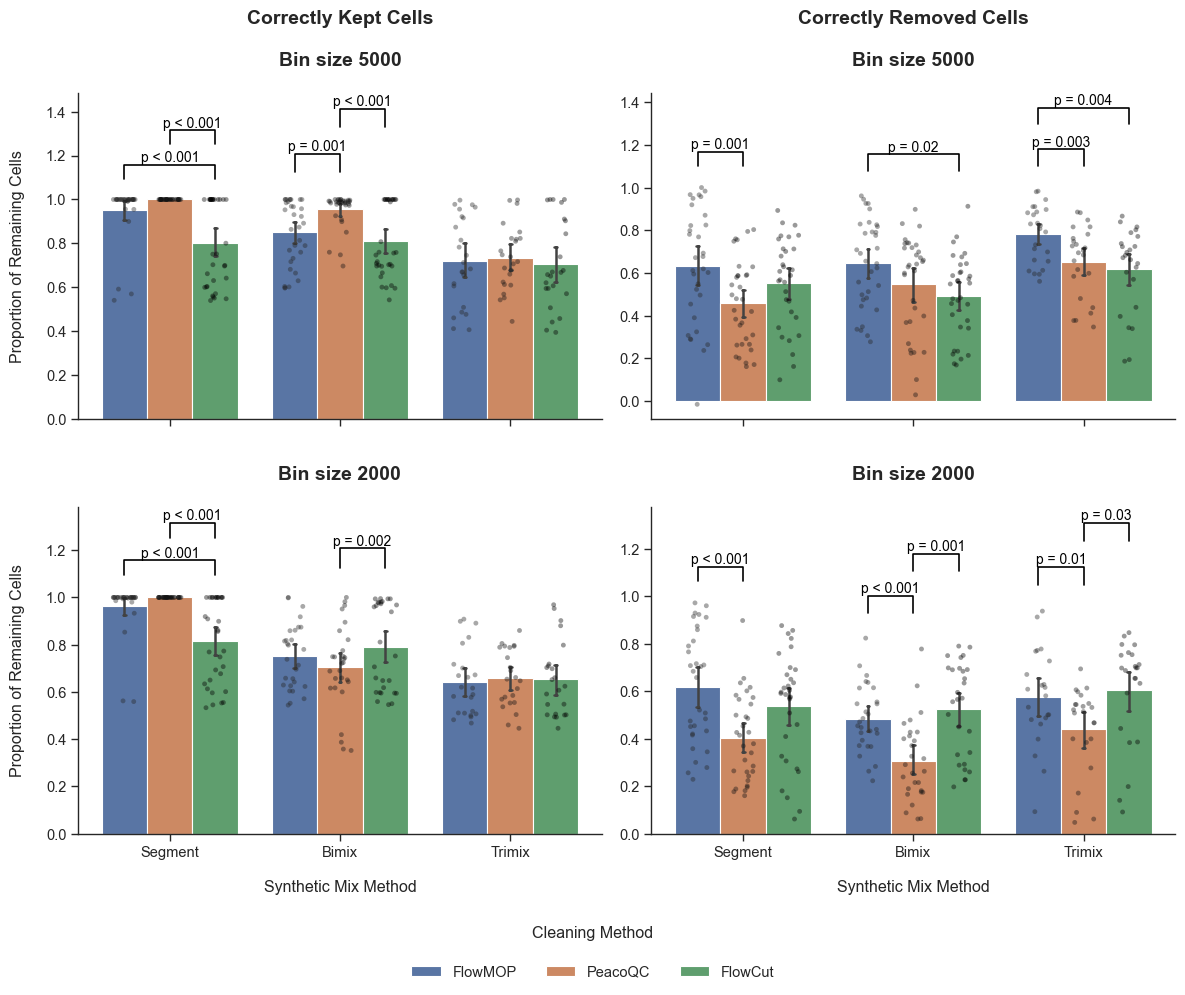

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from scipy.stats import ttest_rel
from itertools import combinations

# --- Helper function for formatting p-values ---
def format_p_value(p):
    if p < 0.001:
        return "p < 0.001"
    elif p < 0.01:
        return f"p = {p:.3f}"
    else: # p-values between 0.01 and 0.05
        return f"p = {p:.2f}"

# --- Helper function to add statistical annotations (REVISED for Paired T-test) ---
def add_stat_annotation(ax, data, y_col, mix_methods_order, clean_methods_order):
    """
    Performs paired t-tests with Bonferroni correction and adds significance brackets.
    """
    n_mix = len(mix_methods_order)
    
    # Iterate over each primary group on the x-axis
    for mix_idx, mix_method in enumerate(mix_methods_order):
        
        sub_df = data[data['mix_method'] == mix_method]
        
        if len(sub_df['clean_method'].unique()) < 2:
            continue
            
        # --- Paired T-test Logic ---
        # Pivot the data to align samples by 'sample_name' and 'proportion'
        pivoted_df = sub_df.pivot(index=['sample_name', 'proportion'], columns='clean_method', values=y_col)

        # Get all pairwise combinations of cleaning methods
        comparisons = list(combinations(clean_methods_order, 2))
        m = len(comparisons) # Bonferroni correction factor
        sig_results = []
        for group1, group2 in comparisons:
            # Drop rows with NaNs for the pair to ensure samples are properly paired
            pair_df = pivoted_df[[group1, group2]].dropna()
            
            if len(pair_df) < 2: # Need at least 2 pairs for a t-test
                continue

            # Perform the paired t-test
            stat, p_raw = ttest_rel(pair_df[group1], pair_df[group2])
            # Apply Bonferroni correction
            p_adj = min(p_raw * m, 1.0)
            
            if p_adj < 0.05:
                sig_results.append({'group1': group1, 'group2': group2, 'p-adj': p_adj})

        if not sig_results:
            continue
            
        # --- Drawing Logic ---
        group_max = sub_df[y_col].max()
        y_range = ax.get_ylim()[1] - ax.get_ylim()[0]
        y_offset = y_range * 0.06
        
        current_y = group_max + y_offset * 1.5
        
        for result in sig_results:
            group1, group2 = result['group1'], result['group2']
            p_val = result['p-adj']
            
            clean_idx1 = clean_methods_order.index(group1)
            clean_idx2 = clean_methods_order.index(group2)
            
            bar1 = ax.patches[clean_idx1 * n_mix + mix_idx]
            bar2 = ax.patches[clean_idx2 * n_mix + mix_idx]
            x1, x2 = bar1.get_x() + bar1.get_width() / 2, bar2.get_x() + bar2.get_width() / 2
            
            ax.plot([x1, x1, x2, x2], [current_y, current_y + y_offset, current_y + y_offset, current_y], lw=1.2, c='black')
            ax.text((x1 + x2) / 2, current_y + y_offset, format_p_value(p_val), ha='center', va='bottom', color='black', fontsize=10)
            
            current_y += y_offset * 2.5


# --- Main plotting script for 2x2 layout: bin sizes vs correct keep/remove ---

# Prepare data
alltime_normal.reset_index(drop=True, inplace=True)
alltime_normal['mix_method'] = alltime_normal['mix_method'].str.capitalize()

alltime_smallcut.reset_index(drop=True, inplace=True) 
alltime_smallcut['mix_method'] = alltime_smallcut['mix_method'].str.capitalize()

sns.set_theme(style="ticks", context="paper", font_scale=1.2)

# New 2x2 layout: rows = bin sizes, columns = correct keep/remove only
subplot_titles = [
    ["Correctly Kept Cells\n \nBin size 5000", "Correctly Removed Cells\n \nBin size 5000"],
    ["\nBin size 2000", "\nBin size 2000"]
]

y_cols = ['correct_keep_overall', 'correct_remove_overall']
mix_methods_order = ["Segment", "Bimix", "Trimix"]
clean_methods_order = ["flowmop", "peacoqc", "flowcut"]
label_titles = ["FlowMOP", "PeacoQC", "FlowCut"]

fig, axes = plt.subplots(2, 2, figsize=(12, 10), sharex=True)

handles, labels = None, None

# Plot each panel
for row in range(2):  # bin sizes
    data_subset = alltime_normal if row == 0 else alltime_smallcut
    
    for col in range(2):  # correct keep/remove
        ax = axes[row, col]
        y_col = y_cols[col]

        sns.barplot(
            data=data_subset, x='mix_method', y=y_col, hue='clean_method',
            order=mix_methods_order, hue_order=clean_methods_order, ax=ax,
            errorbar=('ci', 95), capsize=.05, palette='deep'
        )
        sns.stripplot(
            data=data_subset, x='mix_method', y=y_col, hue='clean_method',
            order=mix_methods_order, hue_order=clean_methods_order, ax=ax,
            dodge=True, color='black', s=3.5, alpha=0.4, jitter=0.2, legend=False
        )
        
        ax.set_title(subplot_titles[row][col], loc='center', fontsize=14, weight='bold', pad=20)
        
        # Y-axis labels only on left column
        if col == 0:
            if 'keep' in y_col:
                ax.set_ylabel("Proportion of Remaining Cells", labelpad=15)
            elif 'remove' in y_col:
                ax.set_ylabel("Proportion of Removed Cells", labelpad=15)
        else:
            ax.set_ylabel("")
            
        # X-axis labels only on bottom row
        if row == 1:
            ax.set_xlabel("Synthetic Mix Method", labelpad=15)
        else:
            ax.set_xlabel("")
            
        if row == 0 and col == 0:
            handles, labels = ax.get_legend_handles_labels()
        if ax.get_legend() is not None:
            ax.get_legend().remove()
            
        add_stat_annotation(ax, data_subset, y_col, mix_methods_order, clean_methods_order)
        


legend = fig.legend(
    handles, label_titles, title='Cleaning Method\n', bbox_to_anchor=(0.5, 0),
    loc='lower center', ncol=len(labels), frameon=False
)
plt.setp(legend.get_title(), multialignment='center')

sns.despine(fig)
plt.tight_layout(rect=[0, 0.08, 1, 1])
plt.show()

C:\Users\Tony\AppData\Local\Temp\ipykernel_27040\824428489.py:117: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(
C:\Users\Tony\AppData\Local\Temp\ipykernel_27040\824428489.py:117: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(
C:\Users\Tony\AppData\Local\Temp\ipykernel_27040\824428489.py:117: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(
C:\Users\Tony\AppData\Local\Temp\ipykernel_27040\824428489.py:117: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(


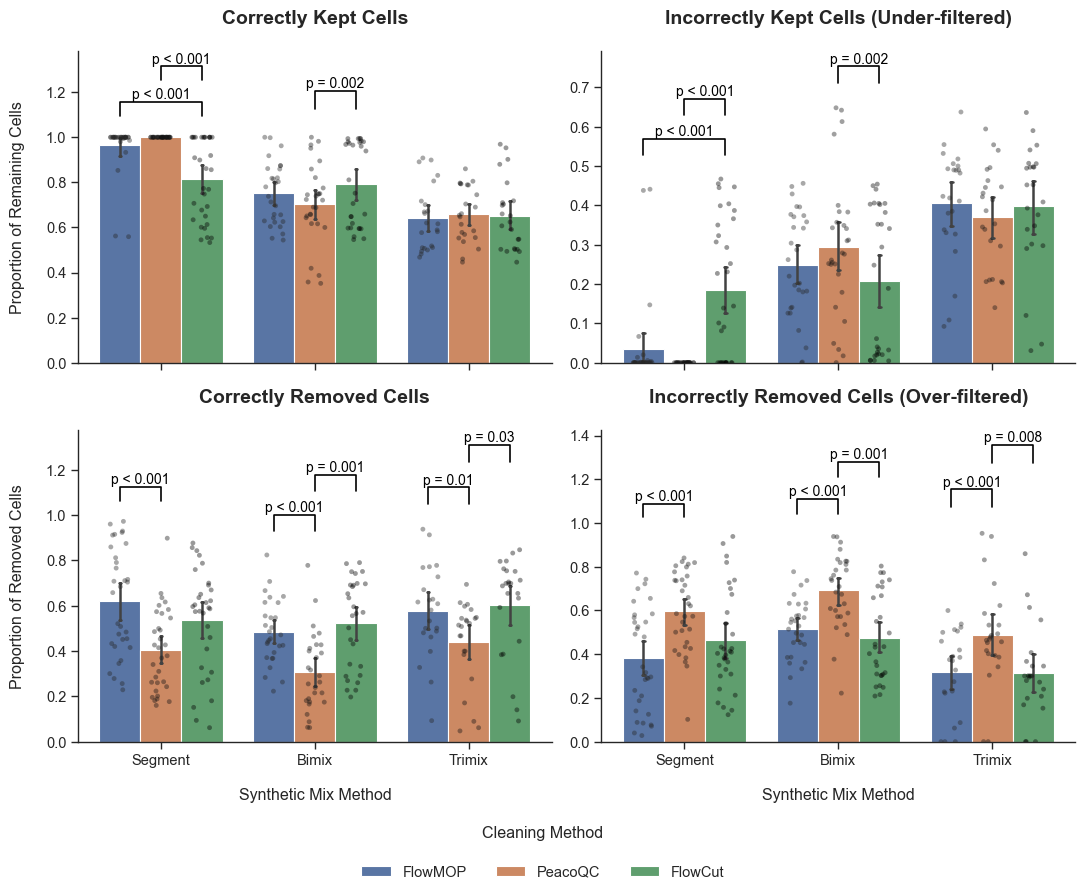

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from scipy.stats import ttest_rel
from itertools import combinations

# --- Helper function for formatting p-values ---
def format_p_value(p):
    if p < 0.001:
        return "p < 0.001"
    elif p < 0.01:
        return f"p = {p:.3f}"
    else: # p-values between 0.01 and 0.05
        return f"p = {p:.2f}"

# --- Helper function to add statistical annotations (REVISED for Paired T-test) ---
def add_stat_annotation(ax, data, y_col, mix_methods_order, clean_methods_order):
    """
    Performs paired t-tests with Bonferroni correction and adds significance brackets.
    """
    n_mix = len(mix_methods_order)
    
    # Iterate over each primary group on the x-axis
    for mix_idx, mix_method in enumerate(mix_methods_order):
        
        sub_df = data[data['mix_method'] == mix_method]
        
        if len(sub_df['clean_method'].unique()) < 2:
            continue
            
        # --- Paired T-test Logic ---
        # Pivot the data to align samples by 'sample_name' and 'proportion'
        pivoted_df = sub_df.pivot(index=['sample_name', 'proportion'], columns='clean_method', values=y_col)

        # Get all pairwise combinations of cleaning methods
        comparisons = list(combinations(clean_methods_order, 2))
        m = len(comparisons) # Bonferroni correction factor
        sig_results = []
        for group1, group2 in comparisons:
            # Drop rows with NaNs for the pair to ensure samples are properly paired
            pair_df = pivoted_df[[group1, group2]].dropna()
            
            if len(pair_df) < 2: # Need at least 2 pairs for a t-test
                continue

            # Perform the paired t-test
            stat, p_raw = ttest_rel(pair_df[group1], pair_df[group2])
            # Apply Bonferroni correction
            p_adj = min(p_raw * m, 1.0)
            
            if p_adj < 0.05:
                sig_results.append({'group1': group1, 'group2': group2, 'p-adj': p_adj})

        if not sig_results:
            continue
            
        # --- Drawing Logic ---
        group_max = sub_df[y_col].max()
        y_range = ax.get_ylim()[1] - ax.get_ylim()[0]
        y_offset = y_range * 0.06
        
        current_y = group_max + y_offset * 1.5
        
        for result in sig_results:
            group1, group2 = result['group1'], result['group2']
            p_val = result['p-adj']
            
            clean_idx1 = clean_methods_order.index(group1)
            clean_idx2 = clean_methods_order.index(group2)
            
            bar1 = ax.patches[clean_idx1 * n_mix + mix_idx]
            bar2 = ax.patches[clean_idx2 * n_mix + mix_idx]
            x1, x2 = bar1.get_x() + bar1.get_width() / 2, bar2.get_x() + bar2.get_width() / 2
            
            ax.plot([x1, x1, x2, x2], [current_y, current_y + y_offset, current_y + y_offset, current_y], lw=1.2, c='black')
            ax.text((x1 + x2) / 2, current_y + y_offset, format_p_value(p_val), ha='center', va='bottom', color='black', fontsize=10)
            
            current_y += y_offset * 2.5


# --- Main plotting script ---

# --- Main plotting script ---

alltime_smallcut.reset_index(drop=True, inplace=True)
alltime_smallcut['mix_method'] = alltime_smallcut['mix_method'].str.capitalize() # Capitalize for plotting

sns.set_theme(style="ticks", context="paper", font_scale=1.2)

subplot_titles = [
    "Correctly Kept Cells", "Incorrectly Kept Cells (Under-filtered)",
    "Correctly Removed Cells", "Incorrectly Removed Cells (Over-filtered)"
]
y_cols = [
    'correct_keep_overall', 'incorrect_keep_overall',
    'correct_remove_overall', 'incorrect_remove_overall'
]
mix_methods_order = ["Segment", "Bimix", "Trimix"] # Use capitalized names
clean_methods_order = ["flowmop", "peacoqc", "flowcut"]

label_titles = ["FlowMOP", "PeacoQC", "FlowCut"]

fig, axes = plt.subplots(2, 2, figsize=(11, 9), sharex=True)
axes = axes.flatten()

handles, labels = None, None

for i, ax in enumerate(axes):
    y_col = y_cols[i]

    sns.barplot(
        data=alltime_smallcut, x='mix_method', y=y_col, hue='clean_method',
        order=mix_methods_order, hue_order=clean_methods_order, ax=ax,
        errorbar=('ci', 95), capsize=.05, palette='deep'
    )
    sns.stripplot(
        data=alltime_smallcut, x='mix_method', y=y_col, hue='clean_method',
        order=mix_methods_order, hue_order=clean_methods_order, ax=ax,
        dodge=True, color='black', s=3.5, alpha=0.4, jitter=0.2, legend=False
    )
    
    ax.set_title(subplot_titles[i], loc='center', fontsize=14, weight='bold', pad=20)
    
    if i % 2 == 0:
        if 'keep' in y_cols[i].lower():
            ax.set_ylabel("Proportion of Remaining Cells", labelpad=15)
        elif 'remove' in y_cols[i].lower():
            ax.set_ylabel("Proportion of Removed Cells", labelpad=15)
    else:
        ax.set_ylabel("")
        
    if i < 2:
        ax.set_xlabel("")
    else:
        ax.set_xlabel("Synthetic Mix Method", labelpad=15)
        
    if i == 0:
        handles, labels = ax.get_legend_handles_labels()
    if ax.get_legend() is not None:
        ax.get_legend().remove()
        
    add_stat_annotation(ax, alltime_smallcut, y_col, mix_methods_order, clean_methods_order)


legend = fig.legend(
    handles, label_titles, title='Cleaning Method\n', bbox_to_anchor=(0.5, 0),
    loc='lower center', ncol=len(labels), frameon=False
)
plt.setp(legend.get_title(), multialignment='center')

sns.despine(fig)
plt.tight_layout(rect=[0, 0.08, 1, 1])
plt.show()